# Diabetes Regression Project

## End-to-End Machine Learning Workflow

In [5]:
from sklearn.datasets import load_diabetes

diabetes = load_diabetes(as_frame=True)

In [6]:
X = diabetes.data
y = diabetes.target

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (442, 10)
y shape: (442,)


In [3]:
X.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641


In [4]:
y.head()

0    151.0
1     75.0
2    141.0
3    206.0
4    135.0
Name: target, dtype: float64

In [5]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 442 entries, 0 to 441
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   age     442 non-null    float64
 1   sex     442 non-null    float64
 2   bmi     442 non-null    float64
 3   bp      442 non-null    float64
 4   s1      442 non-null    float64
 5   s2      442 non-null    float64
 6   s3      442 non-null    float64
 7   s4      442 non-null    float64
 8   s5      442 non-null    float64
 9   s6      442 non-null    float64
dtypes: float64(10)
memory usage: 34.7 KB


In [6]:
X.describe()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
count,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02
mean,-2.511817e-19,1.230790e-17,-2.245564e-16,-4.797570e-17,-1.381499e-17,3.918434e-17,-5.777179e-18,-9.042540e-18,9.268604e-17,1.130318e-17
std,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02
min,-1.072256e-01,-4.464164e-02,-9.027530e-02,-1.123988e-01,-1.267807e-01,-1.156131e-01,-1.023071e-01,-7.639450e-02,-1.260971e-01,-1.377672e-01
25%,-3.729927e-02,-4.464164e-02,-3.422907e-02,-3.665608e-02,-3.424784e-02,-3.035840e-02,-3.511716e-02,-3.949338e-02,-3.324559e-02,-3.317903e-02
50%,5.383060e-03,-4.464164e-02,-7.283766e-03,-5.670422e-03,-4.320866e-03,-3.819065e-03,-6.584468e-03,-2.592262e-03,-1.947171e-03,-1.077698e-03
75%,3.807591e-02,5.068012e-02,3.124802e-02,3.564379e-02,2.835801e-02,2.984439e-02,2.931150e-02,3.430886e-02,3.243232e-02,2.791705e-02
max,1.107267e-01,5.068012e-02,1.705552e-01,1.320436e-01,1.539137e-01,1.987880e-01,1.811791e-01,1.852344e-01,1.335973e-01,1.356118e-01


In [7]:
y.describe()

count    442.000000
mean     152.133484
std       77.093005
min       25.000000
25%       87.000000
50%      140.500000
75%      211.500000
max      346.000000
Name: target, dtype: float64

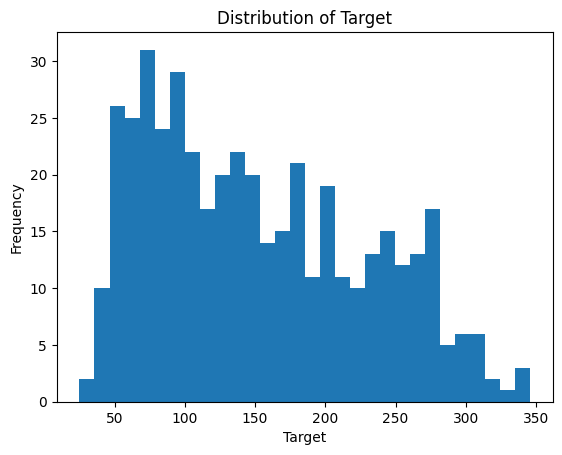

In [8]:
import matplotlib.pyplot as plt

plt.hist(y, bins=30)
plt.xlabel("Target")
plt.ylabel("Frequency")
plt.title("Distribution of Target")
plt.show()

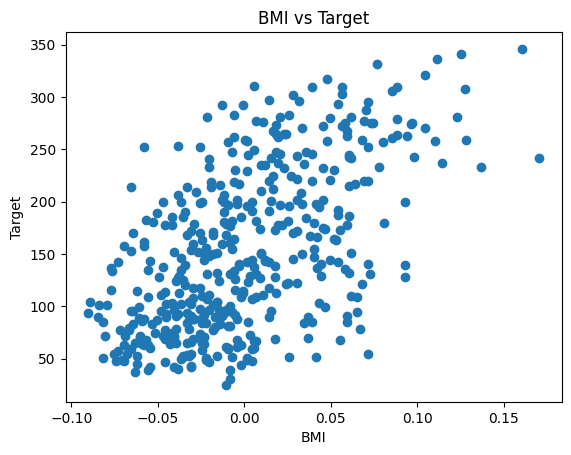

In [9]:
plt.scatter(X["bmi"], y)
plt.xlabel("BMI")
plt.ylabel("Target")
plt.title("BMI vs Target")
plt.show()

In [7]:

correlation = X.corrwith(y)

print(correlation)

age    0.187889
sex    0.043062
bmi    0.586450
bp     0.441482
s1     0.212022
s2     0.174054
s3    -0.394789
s4     0.430453
s5     0.565883
s6     0.382483
dtype: float64


In [8]:
correlation.sort_values(ascending=False)

bmi    0.586450
s5     0.565883
bp     0.441482
s4     0.430453
s6     0.382483
s1     0.212022
age    0.187889
s2     0.174054
sex    0.043062
s3    -0.394789
dtype: float64

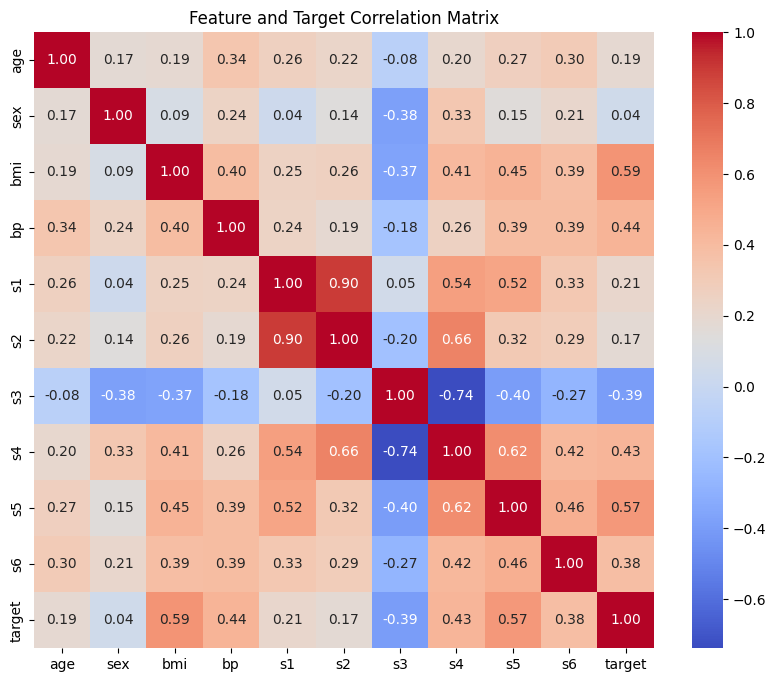

In [10]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

correlation_matrix = pd.concat(
[X, y.rename("target")],
axis=1
).corr()

plt.figure(figsize=(10, 8))

sns.heatmap(
correlation_matrix,
annot=True,
fmt=".2f",
cmap="coolwarm"
)

plt.title("Feature and Target Correlation Matrix")
plt.show()

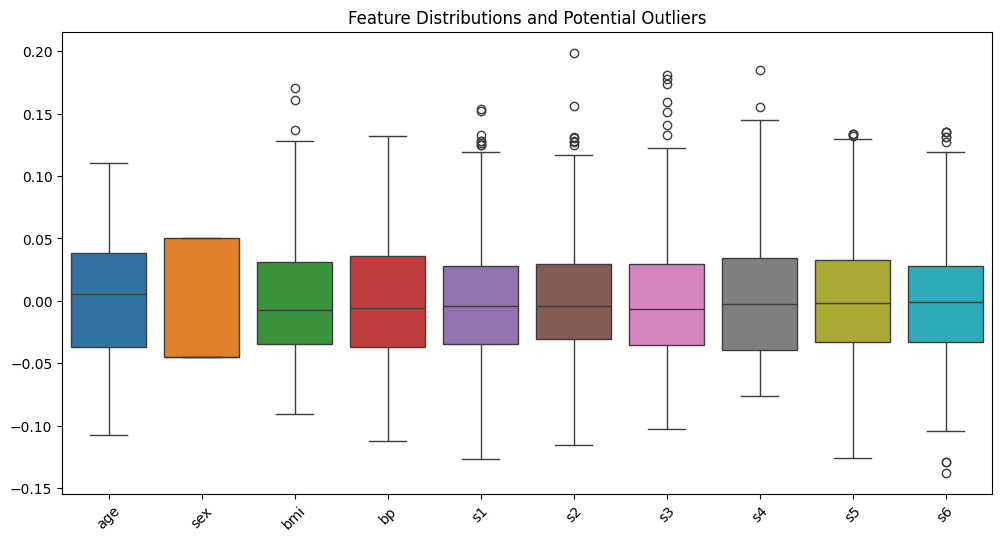

In [11]:

plt.figure(figsize=(12, 6))

sns.boxplot(data=X)

plt.title("Feature Distributions and Potential Outliers")
plt.xticks(rotation=45)
plt.show()

In [12]:

from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(
X,
y,
test_size=0.30,
random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
X_temp,
y_temp,
test_size=0.50,
random_state=42
)

print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("X_test:", X_test.shape)

print("y_train:", y_train.shape)
print("y_val:", y_val.shape)
print("y_test:", y_test.shape)

X_train: (309, 10)
X_val: (66, 10)
X_test: (67, 10)
y_train: (309,)
y_val: (66,)
y_test: (67,)


In [14]:

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_val_scaled = scaler.transform(X_val)

X_test_scaled = scaler.transform(X_test)

print(X_train_scaled.shape)
print(X_val_scaled.shape)
print(X_test_scaled.shape)


(309, 10)
(66, 10)
(67, 10)


In [15]:
from sklearn.linear_model import LinearRegression

linear_model = LinearRegression()

linear_model.fit(X_train_scaled, y_train)

linear_val_pred = linear_model.predict(X_val_scaled)

print(linear_val_pred[:5])

[177.76169318 153.29339984 170.55301782  92.10100436 204.97622269]


In [16]:
from sklearn.metrics import (
r2_score,
mean_absolute_error,
mean_squared_error
)

linear_r2 = r2_score(y_val, linear_val_pred)

linear_mae = mean_absolute_error(
y_val,
linear_val_pred
)

linear_rmse = mean_squared_error(
y_val,
linear_val_pred
) ** 0.5

print("Linear Regression")
print("R²:", linear_r2)
print("MAE:", linear_mae)
print("RMSE:", linear_rmse)

Linear Regression
R²: 0.5112619269090264
MAE: 38.216681372349036
RMSE: 49.9932118860325


In [17]:

from sklearn.linear_model import Ridge

ridge_model = Ridge(alpha=1.0)

ridge_model.fit(X_train_scaled, y_train)

ridge_val_pred = ridge_model.predict(X_val_scaled)

print(ridge_val_pred[:5])

[179.48184812 151.81510635 169.87269794  91.76230334 204.22838622]


In [18]:
ridge_r2 = r2_score(y_val, ridge_val_pred)

ridge_mae = mean_absolute_error(
y_val,
ridge_val_pred
)

ridge_rmse = mean_squared_error(
y_val,
ridge_val_pred
) ** 0.5

print("Ridge Regression")
print("R²:", ridge_r2)
print("MAE:", ridge_mae)
print("RMSE:", ridge_rmse)

Ridge Regression
R²: 0.515129460185924
MAE: 38.07100231937629
RMSE: 49.79501324711064


In [19]:

from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
n_estimators=200,
random_state=42
)

rf_model.fit(X_train, y_train)

rf_val_pred = rf_model.predict(X_val)

print(rf_val_pred[:5])

[209.875 158.795 199.89  104.08  182.54 ]


In [20]:
rf_r2 = r2_score(y_val, rf_val_pred)

rf_mae = mean_absolute_error(
y_val,
rf_val_pred
)

rf_rmse = mean_squared_error(
y_val,
rf_val_pred
) ** 0.5

print("Random Forest")
print("R²:", rf_r2)
print("MAE:", rf_mae)
print("RMSE:", rf_rmse)

Random Forest
R²: 0.47111784455874683
MAE: 39.25083333333334
RMSE: 52.005875320035045


In [21]:
from sklearn.ensemble import GradientBoostingRegressor

gb_model = GradientBoostingRegressor(
n_estimators=100,
learning_rate=0.05,
max_depth=3,
random_state=42
)

gb_model.fit(X_train, y_train)

gb_val_pred = gb_model.predict(X_val)

print(gb_val_pred[:5])

[196.38108089 152.23870721 159.13097532  95.44716915 197.95871592]


In [22]:
gb_r2 = r2_score(y_val, gb_val_pred)

gb_mae = mean_absolute_error(
y_val,
gb_val_pred
)

gb_rmse = mean_squared_error(
y_val,
gb_val_pred
) ** 0.5

print("Gradient Boosting")
print("R²:", gb_r2)
print("MAE:", gb_mae)
print("RMSE:", gb_rmse)

Gradient Boosting
R²: 0.47980413399541977
MAE: 40.22431501516685
RMSE: 51.577038487471455


In [24]:
results = pd.DataFrame({
"Model": [
"Linear Regression",
"Ridge Regression",
"Random Forest",
"Gradient Boosting"
],
"R2": [
linear_r2,
ridge_r2,
rf_r2,
gb_r2
],
"MAE": [
linear_mae,
ridge_mae,
rf_mae,
gb_mae
],
"RMSE": [
linear_rmse,
ridge_rmse,
rf_rmse,
gb_rmse
]
})

results


,Model,R2,MAE,RMSE
0,Linear Regression,0.511262,38.216681,49.993212
1,Ridge Regression,0.515129,38.071002,49.795013
2,Random Forest,0.471118,39.250833,52.005875
3,Gradient Boosting,0.479804,40.224315,51.577038


In [25]:
from sklearn.model_selection import cross_val_score
cv_scores = cross_val_score(
GradientBoostingRegressor(
n_estimators=100,
learning_rate=0.05,
max_depth=3,
random_state=42
),
X_train,
y_train,
cv=5,
scoring="r2"
)

print("CV R² scores:", cv_scores)
print("Mean CV R²:", cv_scores.mean())
print("Std CV R²:", cv_scores.std())

CV R² scores: [0.44195241 0.00848282 0.51798937 0.57957931 0.30184462]
Mean CV R²: 0.3699697039412518
Std CV R²: 0.20314591466308196


In [26]:
from sklearn.model_selection import RandomizedSearchCV

rf_param_grid = {
"n_estimators": [100, 200, 300, 500],
"max_depth": [None, 5, 10, 15, 20],
"min_samples_split": [2, 5, 10],
"min_samples_leaf": [1, 2, 4]
}

rf_search = RandomizedSearchCV(
estimator=RandomForestRegressor(
random_state=42
),
param_distributions=rf_param_grid,
n_iter=20,
cv=5,
scoring="r2",
random_state=42,
n_jobs=-1
)

rf_search.fit(X_train, y_train)

print("Best parameters:")
print(rf_search.best_params_)

print("Best CV R²:")
print(rf_search.best_score_)

Best parameters:
{'n_estimators': 200, 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_depth': 20}
Best CV R²:
0.39648277836525897


In [27]:
gb_param_grid = {
"n_estimators": [50, 100, 150, 200],
"learning_rate": [0.01, 0.03, 0.05, 0.1],
"max_depth": [2, 3, 4],
"min_samples_split": [2, 5, 10],
"min_samples_leaf": [1, 2, 4]
}

gb_search = RandomizedSearchCV(
estimator=GradientBoostingRegressor(
random_state=42
),
param_distributions=gb_param_grid,
n_iter=20,
cv=5,
scoring="r2",
random_state=42,
n_jobs=-1
)

gb_search.fit(X_train, y_train)

print("Best parameters:")
print(gb_search.best_params_)

print("Best CV R²:")
print(gb_search.best_score_)

Best parameters:
{'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': 4, 'learning_rate': 0.01}
Best CV R²:
0.3786478050492487


In [28]:
tuned_results = pd.DataFrame({
"Model": [
"Tuned Random Forest",
"Tuned Gradient Boosting"
],
"CV_R2": [
rf_search.best_score_,
gb_search.best_score_
]
})

tuned_results

,Model,CV_R2
0,Tuned Random Forest,0.396483
1,Tuned Gradient Boosting,0.378648


In [45]:
best_model = gb_search.best_estimator_ if gb_search.best_score_ >= rf_search.best_score_ else rf_search.best_estimator_

best_model_name = "Tuned Gradient Boosting" if gb_search.best_score_ >= rf_search.best_score_ else "Tuned Random Forest"

print("Candidate final model:", best_model_name)


Candidate final model: Tuned Random Forest


In [47]:
final_test_pred = best_model.predict(X_test)

final_r2 = r2_score(
y_test,
final_test_pred
)

final_mae = mean_absolute_error(
y_test,
final_test_pred
)

final_rmse = mean_squared_error(
y_test,
final_test_pred
) ** 0.5

print("Final Model:", best_model_name)
print("Test R²:", final_r2)
print("Test MAE:", final_mae)
print("Test RMSE:", final_rmse)

Final Model: Tuned Random Forest
Test R²: 0.491104229493606
Test MAE: 45.080538130624326
Test RMSE: 53.75406311981634


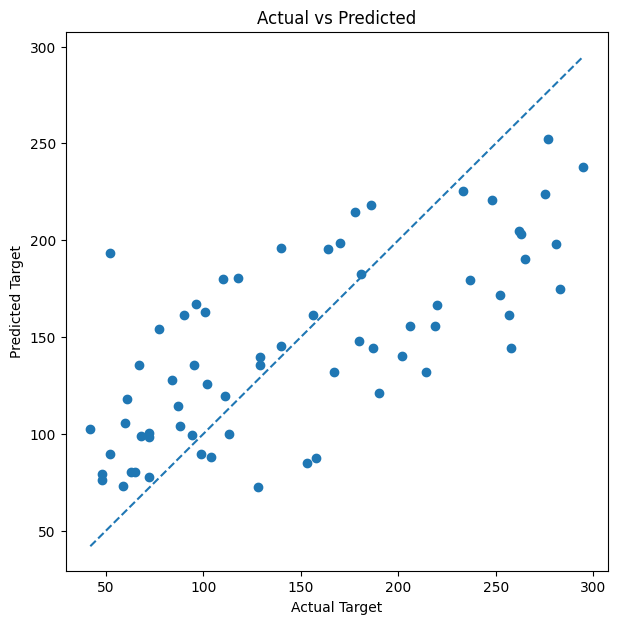

In [48]:
plt.figure(figsize=(7, 7))

plt.scatter(y_test, final_test_pred)

plt.xlabel("Actual Target")
plt.ylabel("Predicted Target")
plt.title("Actual vs Predicted")
plt.plot(
[y_test.min(), y_test.max()],
[y_test.min(), y_test.max()],
linestyle="--"
)

plt.show()

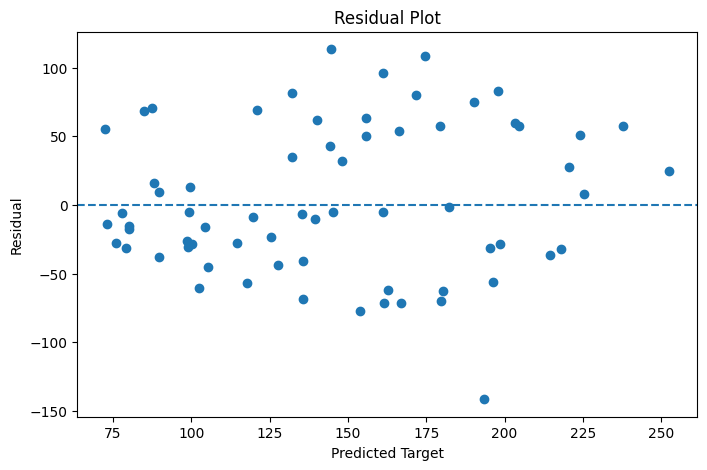

In [49]:

residuals = y_test - final_test_pred

plt.figure(figsize=(8, 5))

plt.scatter(final_test_pred, residuals)

plt.axhline(
0,
linestyle="--"
)

plt.xlabel("Predicted Target")
plt.ylabel("Residual")
plt.title("Residual Plot")

plt.show()

bmi    0.432136
s5     0.177296
bp     0.104131
s6     0.063374
s3     0.052840
age    0.049743
s2     0.043118
s1     0.041012
s4     0.028171
sex    0.008178
dtype: float64


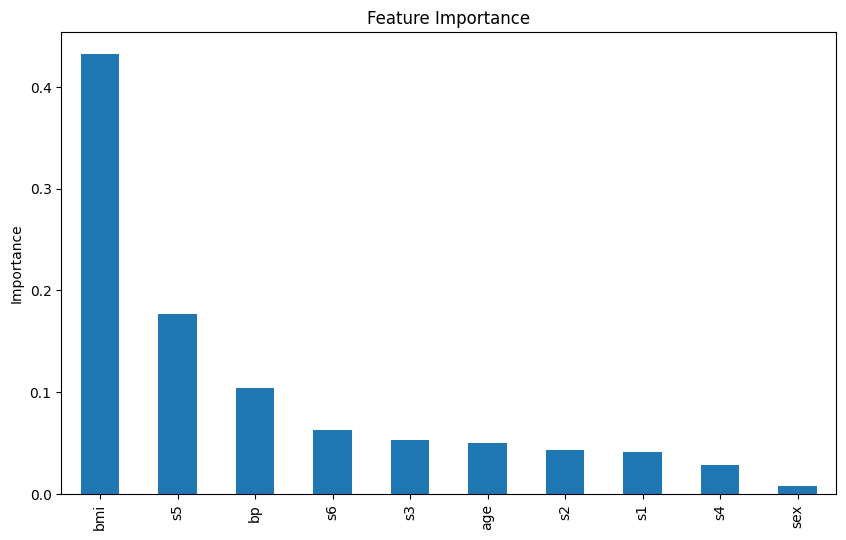

In [53]:

if hasattr(best_model, "feature_importances_"):

 feature_importance = pd.Series(
best_model.feature_importances_,
index=X.columns
).sort_values(ascending=False)

print(feature_importance)

feature_importance.plot(
kind="bar",
figsize=(10, 6)
)

plt.title("Feature Importance")
plt.ylabel("Importance")
plt.show()

In [54]:
import joblib

joblib.dump(
best_model,
"best_model.pkl"
)

print("Model saved successfully!")

Model saved successfully!


In [55]:

joblib.dump(
scaler,
"scaler.pkl"
)

print("Scaler saved successfully!")

Scaler saved successfully!


In [57]:
import json

model_card = {
"model_name": best_model_name,
"dataset": "Diabetes Dataset",
"task": "Regression",
"n_samples": int(X.shape[0]),
"n_features": int(X.shape[1]),
"features": list(X.columns),
"target": "target",
"test_r2": float(final_r2),
"test_mae": float(final_mae),
"test_rmse": float(final_rmse)
}

with open("model_card.json", "w") as f:
 json.dump(
model_card,
f,
indent=4
)

print("Model card saved successfully!")

Model card saved successfully!


In [77]:
import mlflow
import os

mlflow_db = os.path.join(os.getcwd(), "mlflow.db")

mlflow.set_tracking_uri("sqlite:///" + mlflow_db)

mlflow.set_experiment("Diabetes Regression")

with mlflow.start_run(run_name=best_model_name):
    mlflow.log_param("model", best_model_name)
    mlflow.log_metric("test_r2", final_r2)
    mlflow.log_metric("test_mae", final_mae)
    mlflow.log_metric("test_rmse", final_rmse)

print("MLflow run logged successfully!")

2026/09/23 04:08:40 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/09/23 04:08:40 INFO mlflow.store.db.utils: Updating database tables
2026/09/23 04:08:54 INFO mlflow.tracking.fluent: Experiment with name 'Diabetes Regression' does not exist. Creating a new experiment.
2026/09/23 04:08:55 WARNING mlflow.utils.git_utils: Failed to import Git (the Git executable is probably not on your PATH), so Git SHA is not available. Error: Failed to initialize: Bad git executable.
The git executable must be specified in one of the following ways:
    - be included in your $PATH
    - be set via $GIT_PYTHON_GIT_EXECUTABLE
    - explicitly set via git.refresh(<full-path-to-git-executable>)

All git commands will error until this is rectified.

This initial message can be silenced or aggravated in the future by setting the
$GIT_PYTHON_REFRESH environment variable. Use one of the following values:
    - quiet|q|silence|s|silent|none|n|0: for no message or exception
    - war

MLflow run logged successfully!
